In [1]:
# Import libraries and load dataset

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

df = pd.read_csv('bank_customer_churn_prediction.csv')

df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [2]:
# Load Data & Initial Exploration

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


## Data Cleaning & Preparation

In [3]:
# Remove unnecessary column

df = df.drop('customer_id', axis=1)

df.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Exploratory Data Analysis (EDA)

In [4]:
df['churn'].value_counts()

,count
churn,
0,7963
1,2037


### Churn by Age
Customers who churn tend to be older on average, suggesting age may be a relevant factor in customer retention.

In [5]:
df.groupby('churn')['age'].mean()

,age
churn,
0,37.408389
1,44.837997


### Churn by Balance

Customers who churn have higher account balances on average, indicating the bank may be losing high-value clients.

In [6]:
df.groupby('churn')['balance'].mean()

,balance
churn,
0,72745.296779
1,91108.539337


### Churn by Activity Status
Inactive customers are significantly more likely to churn, showing that customer engagement is a key driver of retention.

In [7]:
df.groupby('churn')['active_member'].mean()

,active_member
churn,
0,0.554565
1,0.360825


### Churn by Number of Products
The number of products shows minimal difference between churned and retained customers, suggesting it is not a strong predictor of churn.

In [8]:
df.groupby('churn')['products_number'].mean()

,products_number
churn,
0,1.544267
1,1.475209


### Churn by Country
Customers in Germany have a significantly higher churn rate compared to Spain and France, suggesting strong regional differences in customer behavior or satisfaction.

In [9]:
df.groupby('country')['churn'].mean().sort_values(ascending=False)

,churn
country,
Germany,0.324432
Spain,0.166734
France,0.161548


## Key Insights
- Customers who churn tend to be older on average.
- Customers with higher account balances are more likely to churn, indicating loss of high-value clients.
- Inactive customers show a significantly higher probability of churn, highlighting the importance of engagement.
- The number of products does not appear to strongly influence churn.
- Germany has a significantly higher churn rate compared to other countries, suggesting regional differences in customer behavior.

## Data Preparation for Modeling

In [10]:
# Convert categorical variables to numeric
df = pd.get_dummies(df, drop_first=True)

df.head()

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_Germany,country_Spain,gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


## Train-Test Split

In [11]:
# Define features and target
X = df.drop('churn', axis=1)
y = df['churn']

In [12]:
# Split data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(8000, 11) (2000, 11)


## Model Training (Logistic Regression)

In [13]:
# Initialize model

model = LogisticRegression(max_iter=1000)

# Train model

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

## Model Evaluation

In [14]:
# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8105


### Confusion Matrix

In [15]:
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

[[1532   75]
 [ 304   89]]


### Classification Report

In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.95      0.89      1607
           1       0.54      0.23      0.32       393

    accuracy                           0.81      2000
   macro avg       0.69      0.59      0.60      2000
weighted avg       0.78      0.81      0.78      2000



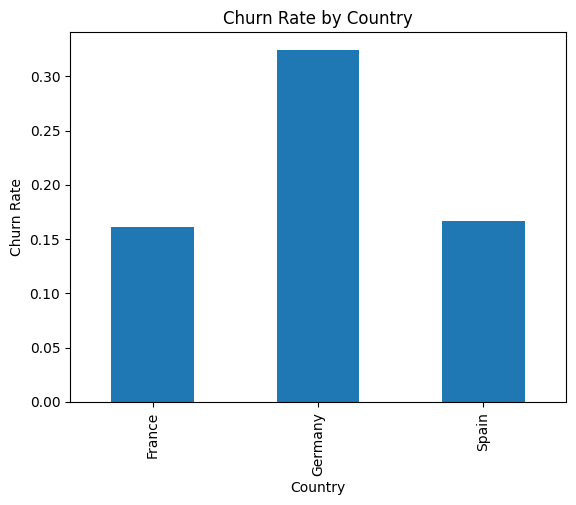

In [20]:
# Recreate country column
df['country'] = 'France'
df.loc[df['country_Germany'] == 1, 'country'] = 'Germany'
df.loc[df['country_Spain'] == 1, 'country'] = 'Spain'

# Group
churn_by_country = df.groupby('country')['churn'].mean()

# Plot
churn_by_country.plot(kind='bar')

plt.title('Churn Rate by Country')
plt.ylabel('Churn Rate')
plt.xlabel('Country')

# Save image
plt.savefig('churn_by_country.png')

plt.show()

## Business Conclusions & Recommendations
- Customers who churn tend to be older and have higher account balances.
- Customer activity is one of the strongest indicators of churn.
- Germany shows significantly higher churn rates, suggesting regional issues.

From a modeling perspective:
- The model achieved reasonable accuracy but struggled to identify churned customers (low recall).
- This limits its effectiveness for proactive retention strategies.

Recommendations:
- Focus on increasing customer engagement to reduce churn.
- Develop targeted retention strategies for high-value customers.
- Investigate specific issues affecting customers in Germany.
- Improve the model by addressing class imbalance or testing more advanced algorithms.